Testing phase diagram of test_critical_pair and train_critical_pair

n = 9
p = 6
q = 4

test_critical_pair = [q, p+1]
train_critical_pair = [q, q+1]

issue! with the train pairs.  

hardcode 

k_o sweep:   0%|          | 0/99 [00:00<?, ?it/s]

test:
break, c_var_val = 0.08510000000000001, k_o = 0.4
train:
break, c_var_val = 2.3326000000000002, k_o = 0.4
test:
break, c_var_val = 0.08760000000000001, k_o = 0.401
train:
break, c_var_val = 2.2826000000000004, k_o = 0.401
test:
break, c_var_val = 0.0901, k_o = 0.402
train:
break, c_var_val = 2.2326, k_o = 0.402
test:
break, c_var_val = 0.0926, k_o = 0.403
train:
break, c_var_val = 2.1826000000000003, k_o = 0.403
test:
break, c_var_val = 0.0951, k_o = 0.404
train:
break, c_var_val = 2.1376000000000004, k_o = 0.404
test:
break, c_var_val = 0.0976, k_o = 0.405
train:
break, c_var_val = 2.0901, k_o = 0.405
test:
break, c_var_val = 0.10010000000000001, k_o = 0.406
train:
break, c_var_val = 2.0476, k_o = 0.406
test:
break, c_var_val = 0.1051, k_o = 0.40700000000000003
train:
break, c_var_val = 2.0026, k_o = 0.40700000000000003
test:
break, c_var_val = 0.1076, k_o = 0.40800000000000003
train:
break, c_var_val = 1.9601, k_o = 0.40800000000000003
test:
break, c_var_val = 0.1101, k_o = 0.4

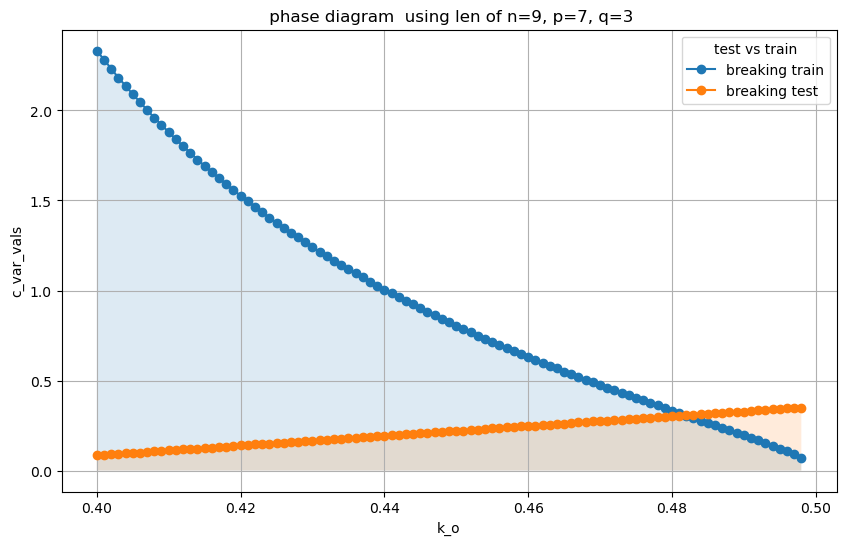

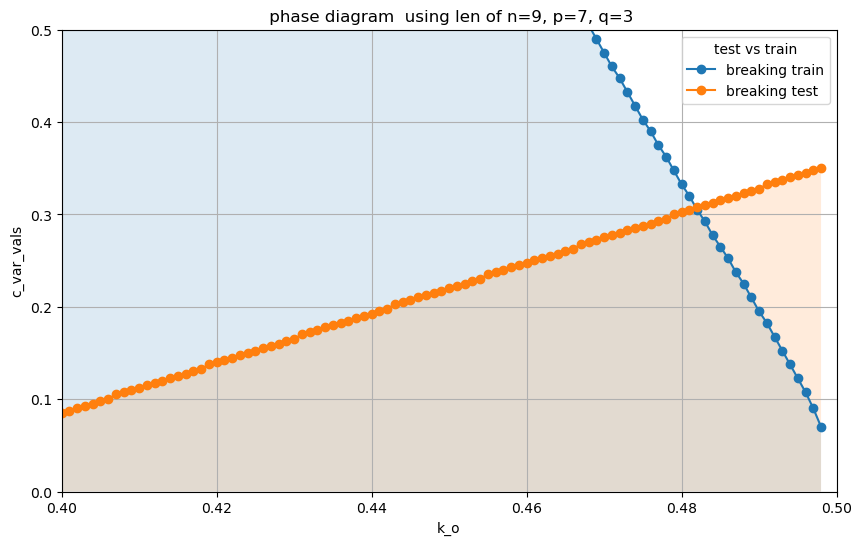

In [1]:
from Ranking_exp import Ranking_exp
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.auto import tqdm

# Set initial parameters
n = 9  # fix n
p = 7
q = 3
k_o_vals = np.arange(.4, 0.499, 0.001)
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 3 
c_var_vals = np.arange(1e-4, 4, 0.0025)
c_vals = 1/(c_var_vals * delta_s)

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]

margin_list_array = []

breaking_reg_test = []
breaking_reg_train = []
for k_o in tqdm(k_o_vals, desc='k_o sweep'):
    
    test_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
        if margin_test<0:
            breaking_reg_test.append(c_var_vals[i])
            print('test:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            test_flag = True
            break
    if test_flag == False:
        breaking_reg_test.append(0)

    train_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
        # print(margin_train)
        if margin_train<0:
            breaking_reg_train.append(c_var_vals[i])
            print('train:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            train_flag = True
            break

    if train_flag == False:
        breaking_reg_train.append(0)


# Plot results

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.40,0.5)
plt.show()


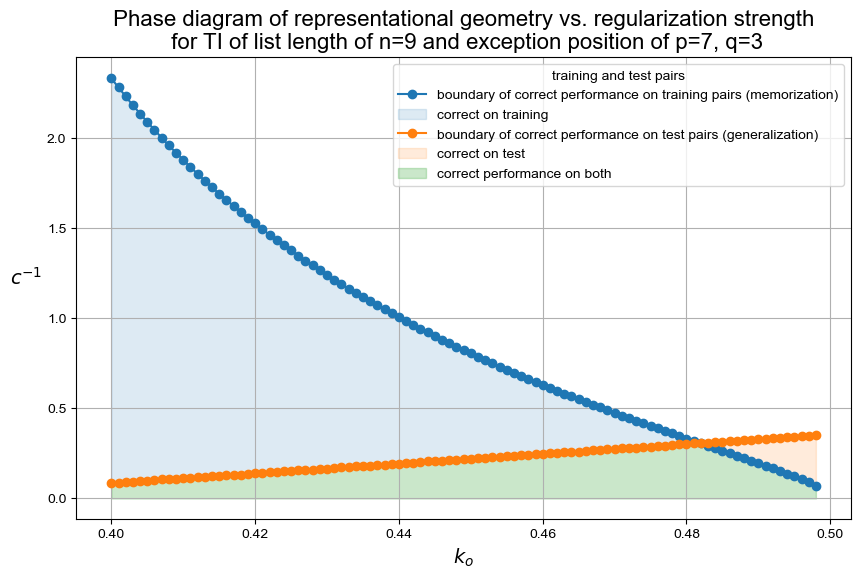

In [2]:
train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.figure(figsize=(10, 6))
plt.title(f' Phase diagram of representational geometry vs. regularization strength \n for TI of list length of n={n} and exception position of p={p}, q={q}', fontsize=16)

plt.plot(k_o_vals, train, marker='o', label='boundary of correct performance on training pairs (memorization)', color='tab:blue')
plt.fill_between(k_o_vals, overlap, train, alpha=0.15, color='tab:blue', label='correct on training')
plt.plot(k_o_vals, test, marker='o', label='boundary of correct performance on test pairs (generalization)', color='tab:orange')
plt.fill_between(k_o_vals, overlap, test, alpha=0.15, color='tab:orange', label='correct on test')

# Shade: blue-only above overlap, orange-only above overlap, then overlap


plt.fill_between(k_o_vals, 0, overlap, alpha=0.25, color='tab:green', label='correct performance on both')

plt.legend(title="training and test pairs")
plt.xlabel(r'$k_o$', fontsize=14)
plt.ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
plt.grid(True)
plt.show()

# Plot professionally

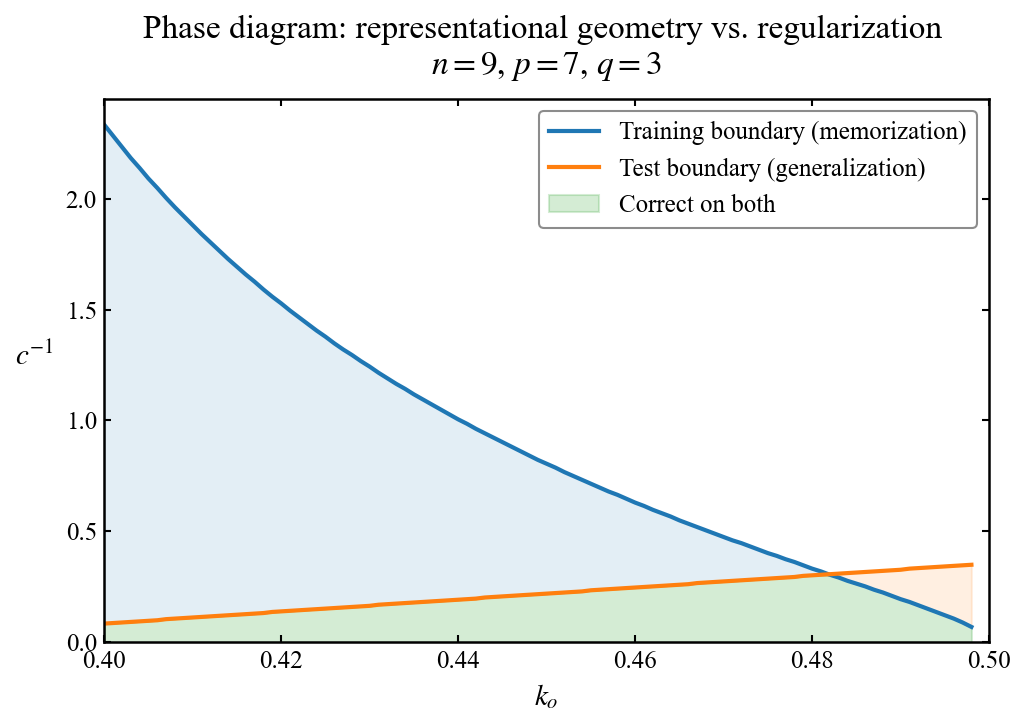

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# -- Global style --
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',        # matches Times
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Lines without markers (cleaner at this density)
ax.plot(k_o_vals, train, linewidth=2, color='#1f77b4',
        label='Training boundary (memorization)')
ax.plot(k_o_vals, test, linewidth=2, color='#ff7f0e',
        label='Test boundary (generalization)')

# Shaded regions first (behind lines)
ax.fill_between(k_o_vals, overlap, train, alpha=0.12, color='#1f77b4')
ax.fill_between(k_o_vals, overlap, test, alpha=0.12, color='#ff7f0e')
ax.fill_between(k_o_vals, 0, overlap, alpha=0.2, color='#2ca02c',
                label='Correct on both')

# Labels
ax.set_xlabel(r'$k_o$', fontsize=14)
ax.set_ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
ax.set_title(
    f'Phase diagram: representational geometry vs. regularization \n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12
)

# Legend
ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray',
          loc='upper right')

# Clean up
ax.set_xlim(0.40, 0.50)
ax.set_ylim(bottom=0)
ax.grid(False)

fig.tight_layout()
plt.show()

In [4]:
print('train min/max:', train.min(), train.max())
print('test min/max:', test.min(), test.max())
print('overlap min/max:', overlap.min(), overlap.max())
print('train - overlap:', (train - overlap)[:10])

train min/max: 0.07010000000000001 2.3326000000000002
test min/max: 0.08510000000000001 0.3501
overlap min/max: 0.07010000000000001 0.3051
train - overlap: [2.2475 2.195  2.1425 2.09   2.0425 1.9925 1.9475 1.8975 1.8525 1.81  ]


In [5]:
!pip install --upgrade ipywidgets

hardcode 

k_o sweep:   0%|          | 0/150 [00:00<?, ?it/s]

test:
break, c_var_val = 0.0001, k_o = 0.35
test:
break, c_var_val = 0.0001, k_o = 0.351
test:
break, c_var_val = 0.0001, k_o = 0.352
test:
break, c_var_val = 0.0001, k_o = 0.353
test:
break, c_var_val = 0.0001, k_o = 0.354
test:
break, c_var_val = 0.0001, k_o = 0.355
test:
break, c_var_val = 0.0001, k_o = 0.356
test:
break, c_var_val = 0.0001, k_o = 0.357
test:
break, c_var_val = 0.0001, k_o = 0.358
test:
break, c_var_val = 0.0001, k_o = 0.359
test:
break, c_var_val = 0.0001, k_o = 0.36
test:
break, c_var_val = 0.0001, k_o = 0.361
test:
break, c_var_val = 0.0001, k_o = 0.362
test:
break, c_var_val = 0.0001, k_o = 0.363
test:
break, c_var_val = 0.0001, k_o = 0.364
test:
break, c_var_val = 0.0001, k_o = 0.365
test:
break, c_var_val = 0.0001, k_o = 0.366
test:
break, c_var_val = 0.0001, k_o = 0.367
test:
break, c_var_val = 0.0001, k_o = 0.368
test:
break, c_var_val = 0.0001, k_o = 0.369
test:
break, c_var_val = 0.0026, k_o = 0.37
test:
break, c_var_val = 0.0076, k_o = 0.371
test:
break, 

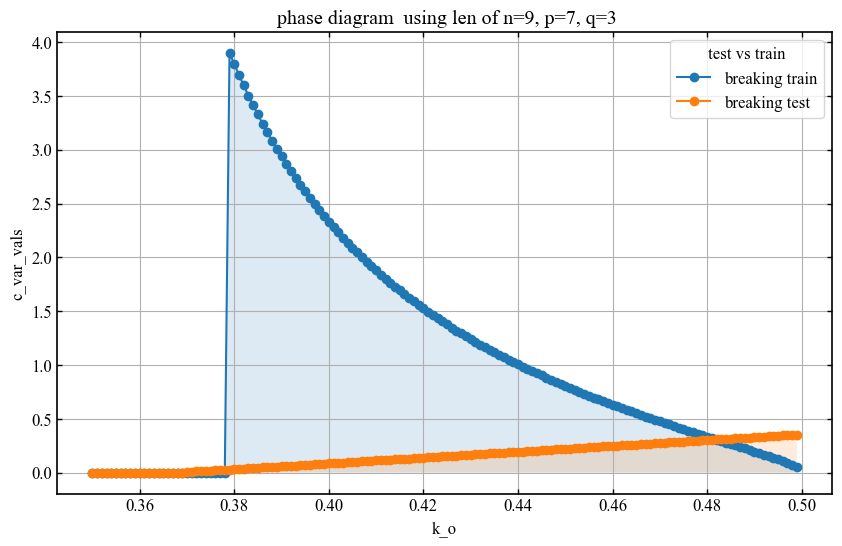

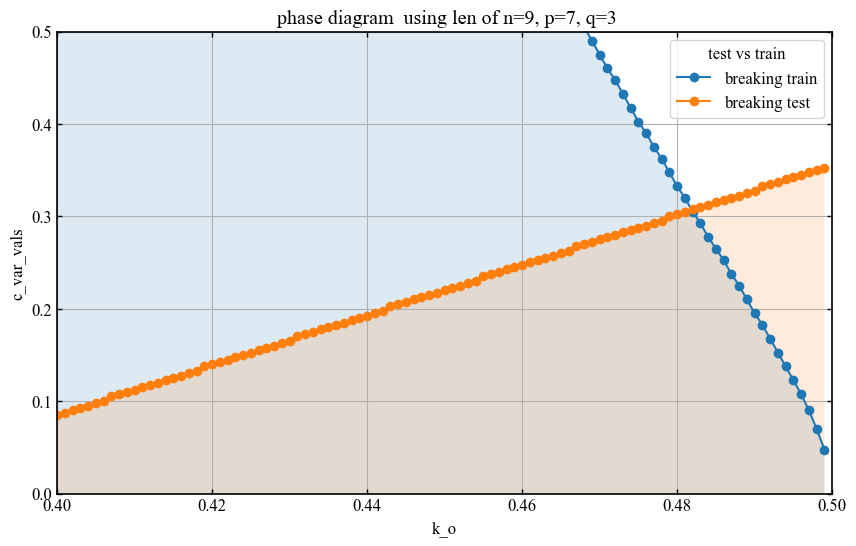

In [6]:
from Ranking_exp import Ranking_exp
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.auto import tqdm

# Set initial parameters
n = 9  # fix n
p = 7
q = 3
k_o_vals = np.arange(.35, 0.499, 0.001)
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 3 
c_var_vals = np.arange(1e-4, 4, 0.0025)
c_vals = 1/(c_var_vals * delta_s)

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]

margin_list_array = []

breaking_reg_test = []
breaking_reg_train = []
for k_o in tqdm(k_o_vals, desc="k_o sweep"):
    
    test_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
        if margin_test<0:
            breaking_reg_test.append(c_var_vals[i])
            print('test:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            test_flag = True
            break
    if test_flag == False:
        breaking_reg_test.append(0)

    train_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
        # print(margin_train)
        if margin_train<0:
            breaking_reg_train.append(c_var_vals[i])
            print('train:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            train_flag = True
            break

    if train_flag == False:
        breaking_reg_train.append(0)


# Plot results

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.40,0.5)
plt.show()


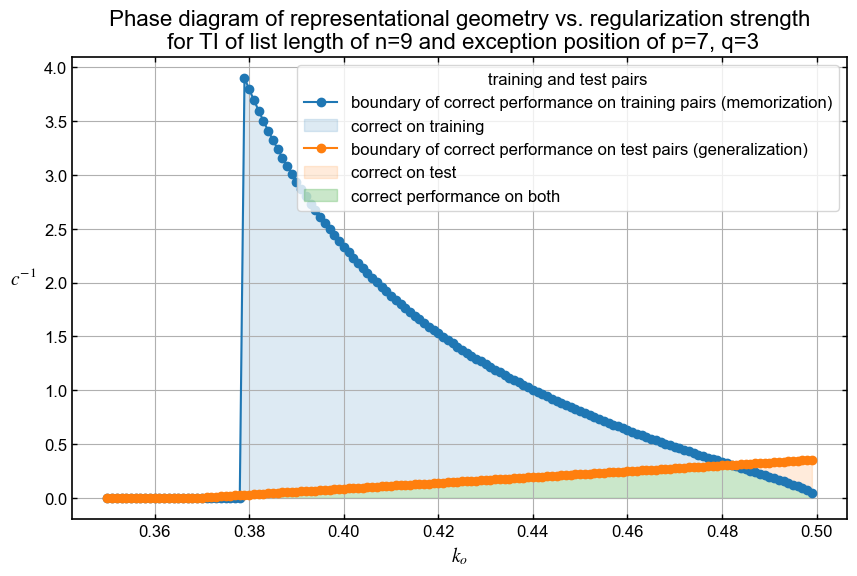

In [7]:
train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.figure(figsize=(10, 6))
plt.title(f' Phase diagram of representational geometry vs. regularization strength \n for TI of list length of n={n} and exception position of p={p}, q={q}', fontsize=16)

plt.plot(k_o_vals, train, marker='o', label='boundary of correct performance on training pairs (memorization)', color='tab:blue')
plt.fill_between(k_o_vals, overlap, train, alpha=0.15, color='tab:blue', label='correct on training')
plt.plot(k_o_vals, test, marker='o', label='boundary of correct performance on test pairs (generalization)', color='tab:orange')
plt.fill_between(k_o_vals, overlap, test, alpha=0.15, color='tab:orange', label='correct on test')

# Shade: blue-only above overlap, orange-only above overlap, then overlap


plt.fill_between(k_o_vals, 0, overlap, alpha=0.25, color='tab:green', label='correct performance on both')

plt.legend(title="training and test pairs")
plt.xlabel(r'$k_o$', fontsize=14)
plt.ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
plt.grid(True)
plt.show()

# Plot professionally

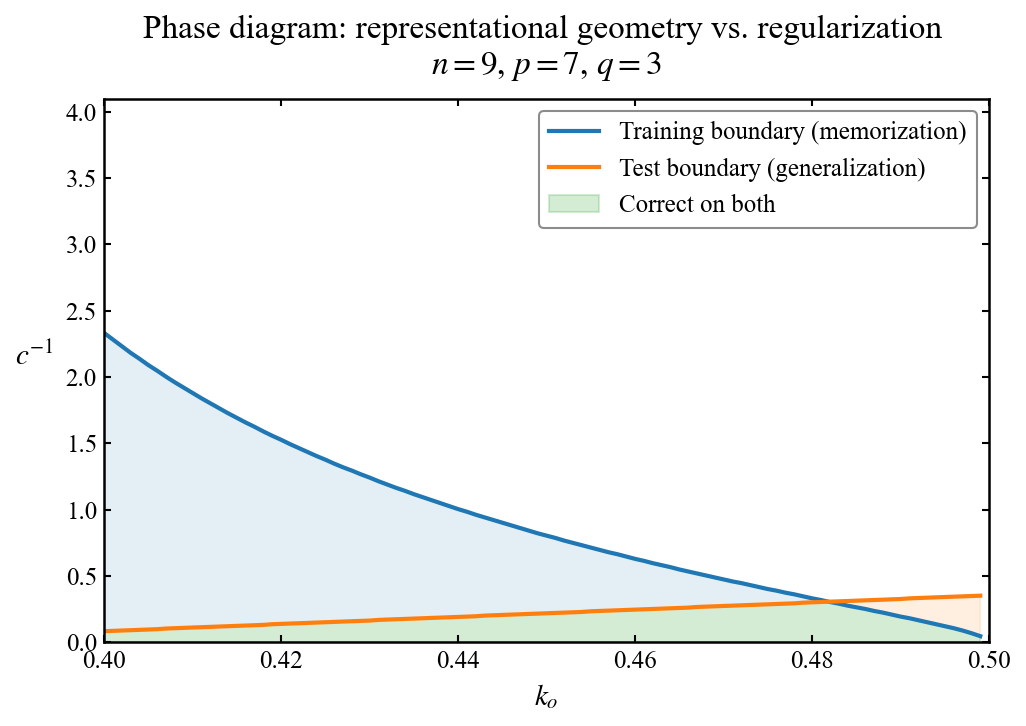

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# -- Global style --
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',        # matches Times
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Lines without markers (cleaner at this density)
ax.plot(k_o_vals, train, linewidth=2, color='#1f77b4',
        label='Training boundary (memorization)')
ax.plot(k_o_vals, test, linewidth=2, color='#ff7f0e',
        label='Test boundary (generalization)')

# Shaded regions first (behind lines)
ax.fill_between(k_o_vals, overlap, train, alpha=0.12, color='#1f77b4')
ax.fill_between(k_o_vals, overlap, test, alpha=0.12, color='#ff7f0e')
ax.fill_between(k_o_vals, 0, overlap, alpha=0.2, color='#2ca02c',
                label='Correct on both')

# Labels
ax.set_xlabel(r'$k_o$', fontsize=14)
ax.set_ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
ax.set_title(
    f'Phase diagram: representational geometry vs. regularization \n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12
)

# Legend
ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray',
          loc='upper right')

# Clean up
ax.set_xlim(0.40, 0.50)
ax.set_ylim(bottom=0)
ax.grid(False)

fig.tight_layout()
plt.show()

In [9]:
print(breaking_reg_test)
print(breaking_reg_train)

[np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0001), np.float64(0.0026), np.float64(0.0076), np.float64(0.0101), np.float64(0.0126), np.float64(0.015099999999999999), np.float64(0.0176), np.float64(0.0201), np.float64(0.0226), np.float64(0.0251), np.float64(0.0276), np.float64(0.0301), np.float64(0.032600000000000004), np.float64(0.035100000000000006), np.float64(0.040100000000000004), np.float64(0.042600000000000006), np.float64(0.0451), np.float64(0.0476), np.float64(0.050100000000000006), np.float64(0.0526), np.float64(0.0551), np.float64(0.057600000000000005), np.float64(0.0601), np.float64(0.0626), np.float64(0.0651), np.float64(0.06760000

# Test Parameters for margin

In [10]:

# Set initial parameters
n = 7  # fix n
p = 5
q = 3
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 4

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]
k_o = 0.4
c_reg = 10
c_reg = 1/(c_reg * delta_s)
sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
ranks = sim.calc_rank_analytic()
margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
print(margin_test)
margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
print(margin_train)

-0.03375365081585895
-0.013621139531207277


hardcode 

k_o sweep:   0%|          | 0/99 [00:00<?, ?it/s]

test:
break, c_var_val = 0.11760000000000001, k_o = 0.4
train:
break, c_var_val = 1.8301, k_o = 0.4
test:
break, c_var_val = 0.1201, k_o = 0.401
train:
break, c_var_val = 1.7876, k_o = 0.401
test:
break, c_var_val = 0.1226, k_o = 0.402
train:
break, c_var_val = 1.7476, k_o = 0.402
test:
break, c_var_val = 0.1251, k_o = 0.403
train:
break, c_var_val = 1.7076, k_o = 0.403
test:
break, c_var_val = 0.1301, k_o = 0.404
train:
break, c_var_val = 1.6701, k_o = 0.404
test:
break, c_var_val = 0.1326, k_o = 0.405
train:
break, c_var_val = 1.6326, k_o = 0.405
test:
break, c_var_val = 0.1351, k_o = 0.406
train:
break, c_var_val = 1.5951, k_o = 0.406
test:
break, c_var_val = 0.1376, k_o = 0.40700000000000003
train:
break, c_var_val = 1.5601, k_o = 0.40700000000000003
test:
break, c_var_val = 0.1401, k_o = 0.40800000000000003
train:
break, c_var_val = 1.5276, k_o = 0.40800000000000003
test:
break, c_var_val = 0.1426, k_o = 0.40900000000000003
train:
break, c_var_val = 1.4926, k_o = 0.409000000000000

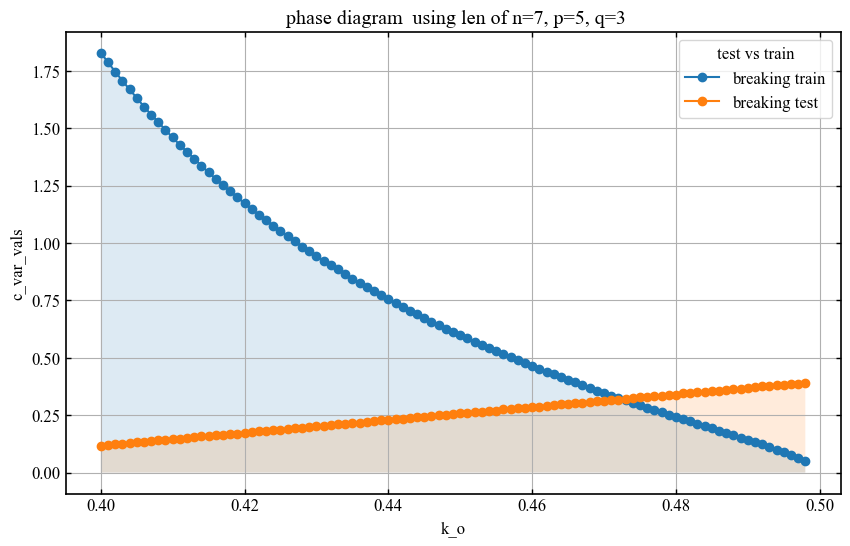

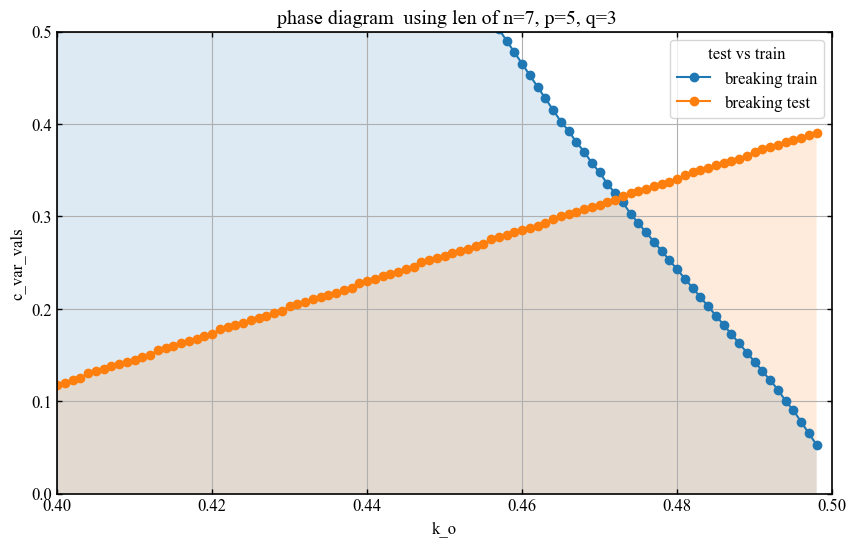

In [11]:
from Ranking_exp import Ranking_exp
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.auto import tqdm

# Set initial parameters
n = 7  # fix n
p = 5
q = 3
k_o_vals = np.arange(.4, 0.499, 0.001)
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 3 
c_var_vals = np.arange(1e-4, 4, 0.0025)
c_vals = 1/(c_var_vals * delta_s)

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]

margin_list_array = []

breaking_reg_test = []
breaking_reg_train = []
for k_o in tqdm(k_o_vals, desc="k_o sweep"):
    
    test_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
        if margin_test<0:
            breaking_reg_test.append(c_var_vals[i])
            print('test:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            test_flag = True
            break
    if test_flag == False:
        breaking_reg_test.append(0)

    train_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
        # print(margin_train)
        if margin_train<0:
            breaking_reg_train.append(c_var_vals[i])
            print('train:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            train_flag = True
            break

    if train_flag == False:
        breaking_reg_train.append(0)


# Plot results

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.fill_between(k_o_vals, breaking_reg_train, alpha=0.15)
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.fill_between(k_o_vals, breaking_reg_test, alpha=0.15)
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.40,0.5)
plt.show()


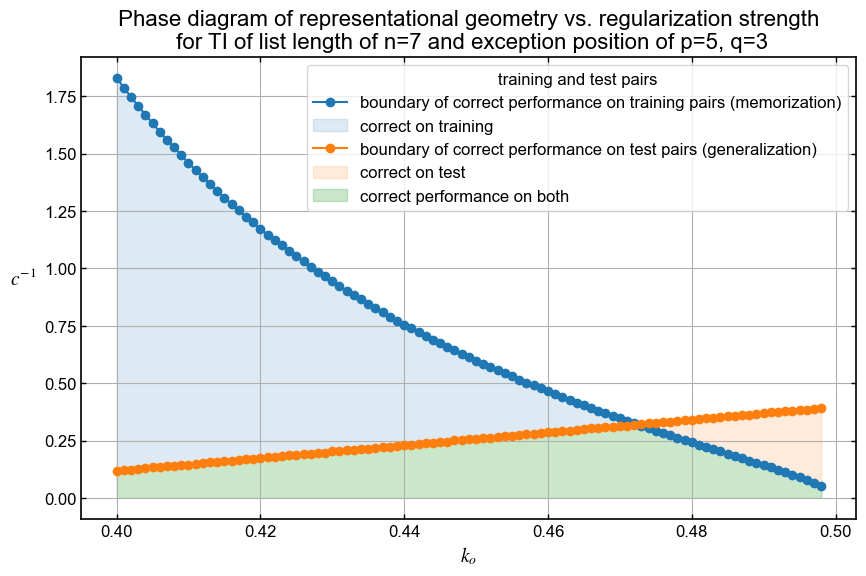

In [12]:
train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.figure(figsize=(10, 6))
plt.title(f' Phase diagram of representational geometry vs. regularization strength \n for TI of list length of n={n} and exception position of p={p}, q={q}', fontsize=16)

plt.plot(k_o_vals, train, marker='o', label='boundary of correct performance on training pairs (memorization)', color='tab:blue')
plt.fill_between(k_o_vals, overlap, train, alpha=0.15, color='tab:blue', label='correct on training')
plt.plot(k_o_vals, test, marker='o', label='boundary of correct performance on test pairs (generalization)', color='tab:orange')
plt.fill_between(k_o_vals, overlap, test, alpha=0.15, color='tab:orange', label='correct on test')

# Shade: blue-only above overlap, orange-only above overlap, then overlap


plt.fill_between(k_o_vals, 0, overlap, alpha=0.25, color='tab:green', label='correct performance on both')

plt.legend(title="training and test pairs")
plt.xlabel(r'$k_o$', fontsize=14)
plt.ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
plt.grid(True)
plt.show()

# Plot professionally

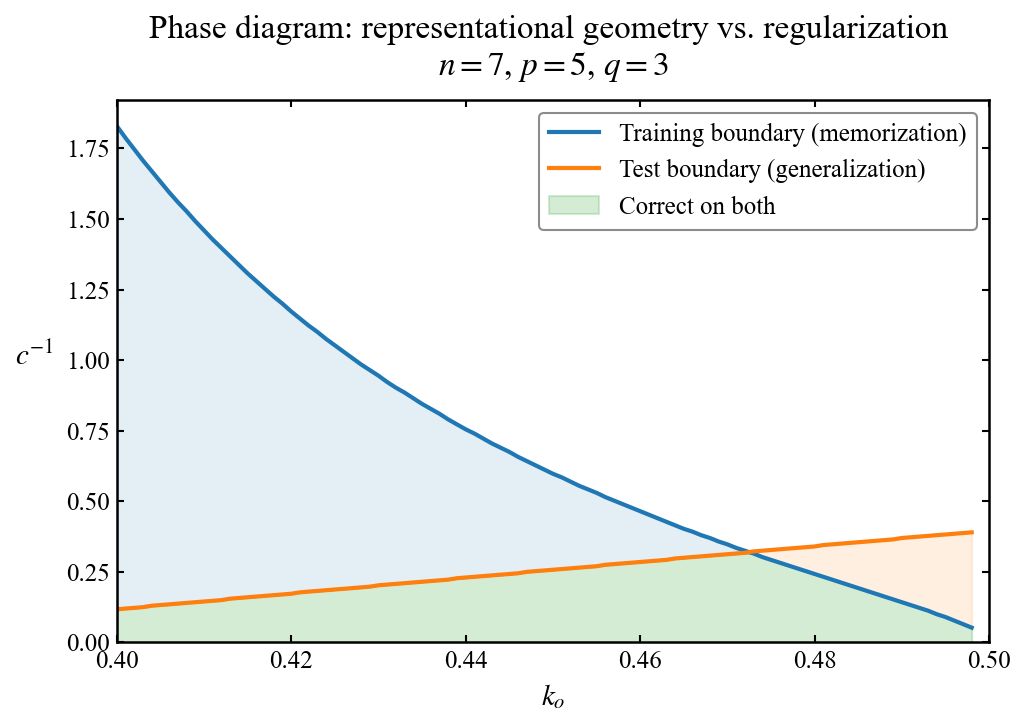

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# -- Global style --
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',        # matches Times
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

train = np.array(breaking_reg_train)
test = np.array(breaking_reg_test)
overlap = np.minimum(train, test)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Lines without markers (cleaner at this density)
ax.plot(k_o_vals, train, linewidth=2, color='#1f77b4',
        label='Training boundary (memorization)')
ax.plot(k_o_vals, test, linewidth=2, color='#ff7f0e',
        label='Test boundary (generalization)')

# Shaded regions first (behind lines)
ax.fill_between(k_o_vals, overlap, train, alpha=0.12, color='#1f77b4')
ax.fill_between(k_o_vals, overlap, test, alpha=0.12, color='#ff7f0e')
ax.fill_between(k_o_vals, 0, overlap, alpha=0.2, color='#2ca02c',
                label='Correct on both')

# Labels
ax.set_xlabel(r'$k_o$', fontsize=14)
ax.set_ylabel(r'$c^{-1}$', fontsize=14, rotation=0, labelpad=15)
ax.set_title(
    f'Phase diagram: representational geometry vs. regularization \n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12
)

# Legend
ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray',
          loc='upper right')

# Clean up
ax.set_xlim(0.40, 0.50)
ax.set_ylim(bottom=0)
ax.grid(False)

fig.tight_layout()
plt.show()

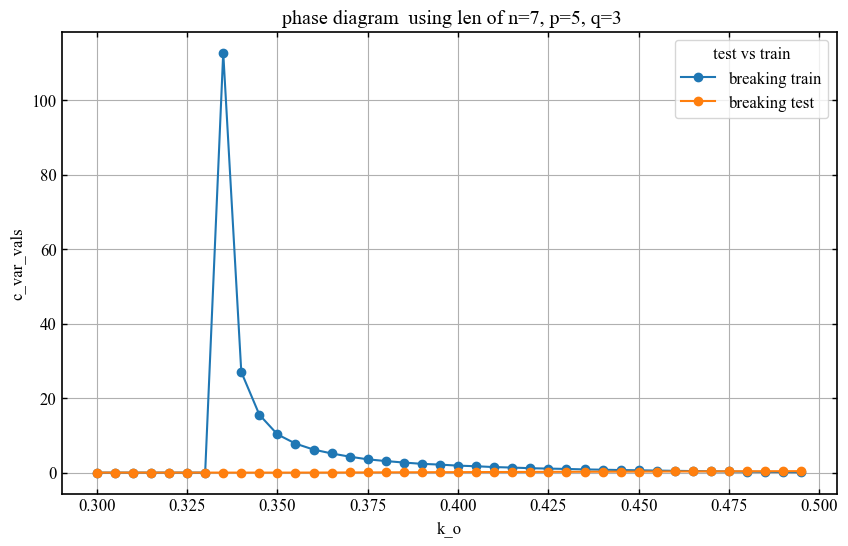

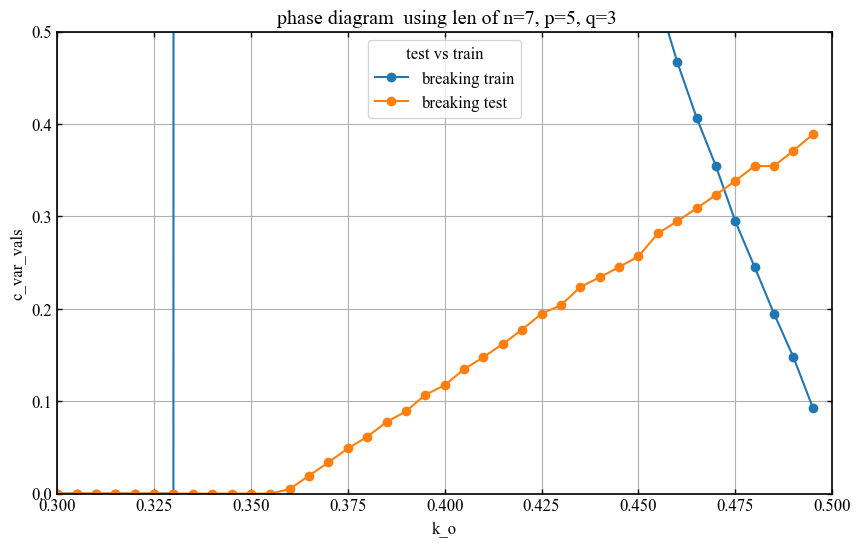

In [14]:
from Ranking_exp import Ranking_exp
import numpy as np
import matplotlib.pyplot as plt
import math

# Set initial parameters
n = 7  # fix n
p = 5
q = 3
k_o_vals = np.arange(.3, 0.499, 0.005)
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 3 
c_var_vals = np.logspace(-10,10,1000)
c_vals = 1/(c_var_vals * delta_s)

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]

margin_list_array = []

breaking_reg_test = []
breaking_reg_train = []
for k_o in k_o_vals:
    
    test_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
        if margin_test<0:
            breaking_reg_test.append(c_var_vals[i])
            # print('test:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            # print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            test_flag = True
            break
    if test_flag == False:
        breaking_reg_test.append(0)

    train_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
        # print(margin_train)
        if margin_train<0:
            breaking_reg_train.append(c_var_vals[i])
            # print('train:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            # print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            train_flag = True
            break

    if train_flag == False:
        breaking_reg_train.append(0)


# Plot results

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.30,0.5)
plt.show()


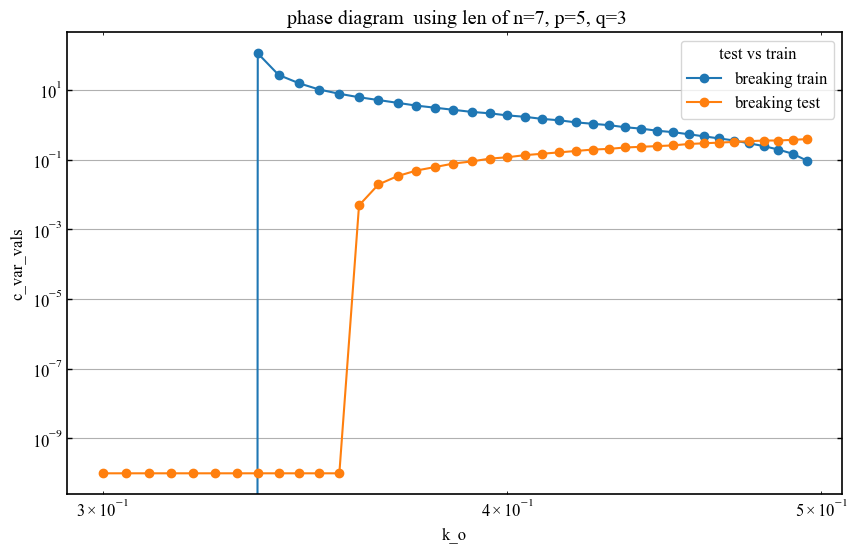

In [15]:
plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

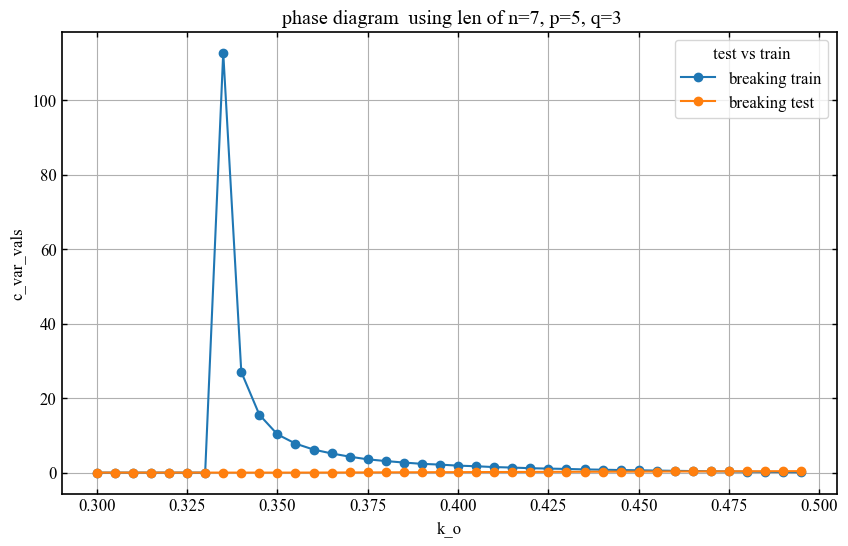

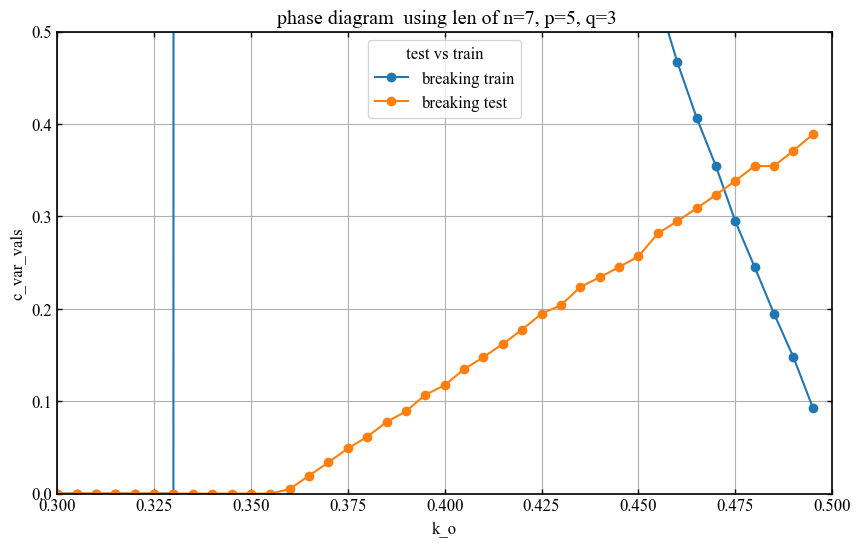

In [16]:
plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.30,0.5)
plt.show()

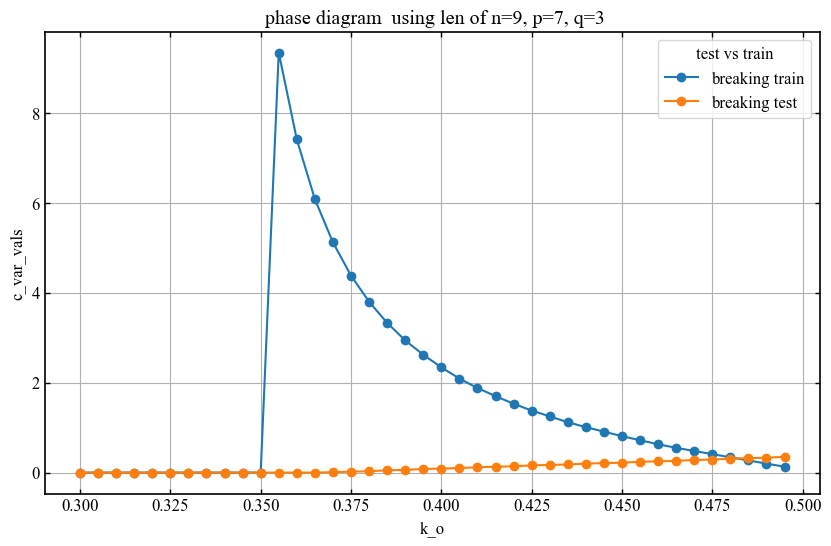

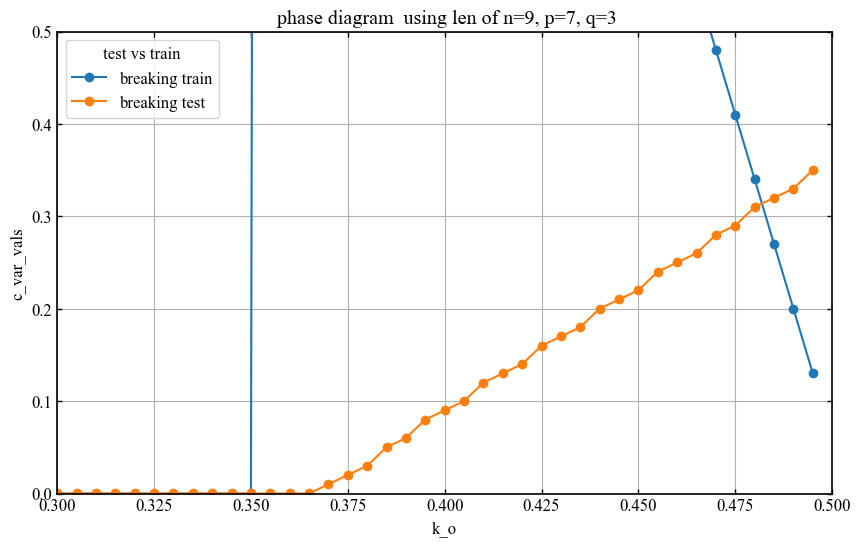

In [17]:
from Ranking_exp import Ranking_exp
import numpy as np
import matplotlib.pyplot as plt
import math

# Set initial parameters
n = 9  # fix n
p = 7
q = 3
k_o_vals = np.arange(.3, 0.499, 0.005)
k_s = 1
k_d = 0
delta_s = k_s - k_d 
excep_len = 3 
c_var_vals = np.arange(1e-4, 10, 0.01)
c_vals = 1/(c_var_vals * delta_s)

test_critical_pair = [q-1, p]
train_critical_pair = [q, q+1]

margin_list_array = []

breaking_reg_test = []
breaking_reg_train = []
for k_o in k_o_vals:
    
    test_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_test = sim.f_j_k(test_critical_pair[0],test_critical_pair[1])
        if margin_test<0:
            breaking_reg_test.append(c_var_vals[i])
            # print('test:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            # print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            test_flag = True
            break
    if test_flag == False:
        breaking_reg_test.append(0)

    train_flag = False
    for i in range(len(c_vals)):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_vals[i])
        ranks = sim.calc_rank_analytic()
        margin_train = sim.f_j_k(train_critical_pair[0],train_critical_pair[1])
        # print(margin_train)
        if margin_train<0:
            breaking_reg_train.append(c_var_vals[i])
            # print('train:')
            # print(f'for k_o = {k_o}, i = {i}, c_var_val = {c_var_vals[i]}')
            # print(f'break, c_var_val = {c_var_vals[i]}, k_o = {k_o}')
            train_flag = True
            break

    if train_flag == False:
        breaking_reg_train.append(0)


# Plot results

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f' phase diagram  using len of n={n}, p={p}, q={q}')
plt.plot(k_o_vals, breaking_reg_train, marker='o', label=f'breaking train')
plt.plot(k_o_vals, breaking_reg_test, marker='o', label=f'breaking test')
plt.legend(title="test vs train")
plt.xlabel('k_o')
plt.ylabel('c_var_vals')
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(0.30,0.5)
plt.show()
